In [ ]:
from lcdb import Debugger

debugger = Debugger()
debugger.load_data(
    workflows=["lcdb.workflow.xgboost.XGBoostWorkflow"],
    openmlids=[3, 1111],
    show_progress=True,
    test_seeds=[0],
    validation_seeds=[0],
    workflow_seeds=[42]
)

In [ ]:
debugger.save_data("debug.csv")

In [3]:
debugger.df

,p:colsample_bytree,p:gamma,p:learning_rate,p:max_depth,p:min_child_weight,p:pp@cat_encoder,p:pp@decomposition,p:pp@featuregen,p:pp@featureselector,p:pp@scaler,...,m:valid_prop,m:test_prop,m:monotonic,m:valid_seed,m:test_seed,m:traceback,m:build_issues,m:timestamp_gather,has_result,traceback_summary
0,0.578627,0.432606,0.000676,15,1.799199,onehot,kernel_pca,none,selectp,std,...,0.1,0.1,True,0.0,0.0,NaN,"{""16"": ""\""Traceback (most recent call last):\n...",3.831790,True,[{'message': 'XGBoostError: [22:00:47] /worksp...
1,1.000000,0.000001,0.300000,6,1.000000,onehot,none,none,none,none,...,0.1,0.1,True,0.0,0.0,NaN,"{""16"": ""\""Traceback (most recent call last):\n...",4.316998,True,[{'message': 'XGBoostError: [22:00:47] /worksp...
2,0.387100,0.131082,0.002076,22,0.000963,ordinal,ka_nystroem,none,selectp,none,...,0.1,0.1,True,0.0,0.0,NaN,"{""16"": ""\""Traceback (most recent call last):\n...",4.516378,True,[{'message': 'XGBoostError: [22:00:48] /worksp...
3,0.624247,0.000008,0.000002,16,0.000365,onehot,lda,none,none,std,...,0.1,0.1,True,0.0,0.0,NaN,"{""16"": ""\""Traceback (most recent call last):\n...",5.413381,True,[{'message': 'XGBoostError: [22:00:48] /worksp...
4,0.850358,18.383245,0.003117,2,0.000002,onehot,lda,none,none,std,...,0.1,0.1,True,0.0,0.0,NaN,"{""16"": ""\""Traceback (most recent call last):\n...",6.300903,True,[{'message': 'XGBoostError: [22:00:49] /worksp...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690,0.578627,0.432606,0.000676,15,1.799199,onehot,kernel_pca,none,selectp,std,...,0.1,0.1,True,0.0,0.0,NaN,"{""16384"": ""timeout""}",1740.161707,True,"[{'message': 'timeout', 'location': 'anchor_16..."
691,0.850358,18.383245,0.003117,2,0.000002,onehot,lda,none,none,std,...,0.1,0.1,True,0.0,0.0,NaN,"{""5793"": ""timeout""}",2487.350157,True,"[{'message': 'timeout', 'location': 'anchor_57..."
692,0.642157,0.000211,0.000011,2,0.013879,onehot,kernel_pca,none,none,std,...,0.1,0.1,True,0.0,0.0,NaN,"{""4096"": ""timeout""}",2860.270968,True,"[{'message': 'timeout', 'location': 'anchor_40..."
693,0.999758,0.000149,0.000008,14,0.000891,ordinal,ka_nystroem,none,none,std,...,0.1,0.1,True,0.0,0.0,NaN,"{""11585"": ""timeout""}",3700.921017,True,"[{'message': 'timeout', 'location': 'anchor_11..."


In [6]:
print(debugger.get_cli_test_command()[0])

lcdb test -i 12 -w lcdb.workflow.xgboost.XGBoostWorkflow --parameters='{"p:colsample_bytree": 0.5786270911568, "p:gamma": 0.4326064713442, "p:learning_rate": 0.000676058337, "p:max_depth": 15, "p:min_child_weight": 1.7991986422815, "p:pp@cat_encoder": "onehot", "p:pp@decomposition": "kernel_pca", "p:pp@featuregen": "none", "p:pp@featureselector": "selectp", "p:pp@scaler": "std", "p:reg_alpha": 7.9103517e-06, "p:reg_lambda": 0.0230245252158, "p:subsample": 0.6411398869467, "p:pp@kernel_pca_kernel": "rbf", "p:pp@kernel_pca_n_components": 0.4557193104768, "p:pp@poly_degree": 2, "p:pp@selectp_percentile": 1, "p:pp@std_with_std": true}'


In [2]:
def get_occurrences_of_error_message(self, msg):
    mask = []
    for openmlid, s in zip(self.df["m:openmlid"], self.df["traceback_summary"]):
        mask.append(any([e["message"] == msg for e in s]))
    return self.df[mask]

for msg in debugger.get_error_messages():
      if "NoneType" in msg:
          print(msg)
          print("\t", list(get_occurrences_of_error_message(debugger, msg)["m:openmlid"]))

TypeError: unsupported operand type(s) for //: 'NoneType' and 'int'
	 [42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0, 42746.0]


<Axes: >

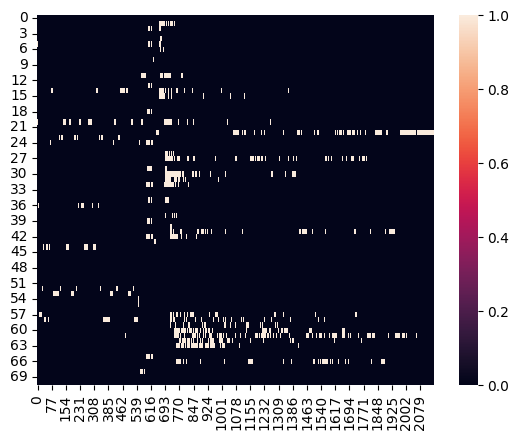

In [5]:
import seaborn as sb
sb.heatmap(debugger.get_error_dataset_matrix())